<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/May2026/4MayConvNeXtBYOL_Hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


🔵 Starting BYOL pretraining...
BYOL Epoch 1 Loss: 0.4173
BYOL Epoch 2 Loss: 0.3732
BYOL Epoch 3 Loss: 0.3229
BYOL Epoch 4 Loss: 0.3180
BYOL Epoch 5 Loss: 0.2125
🟢 Supervised training...
Epoch 1
Train Loss: 1.4466 | Train Acc: 0.3725
Val   Loss: 0.9983 | Val   Acc: 0.6071
Epoch 2
Train Loss: 1.0506 | Train Acc: 0.4955
Val   Loss: 0.7910 | Val   Acc: 0.6964
Epoch 3
Train Loss: 0.8710 | Train Acc: 0.5515
Val   Loss: 0.7167 | Val   Acc: 0.7009
Epoch 4
Train Loss: 0.7864 | Train Acc: 0.5749
Val   Loss: 0.6629 | Val   Acc: 0.7321
Epoch 5
Train Loss: 0.7452 | Train Acc: 0.6029
Val   Loss: 0.6804 | Val   Acc: 0.7143
Epoch 6
Train Loss: 0.6567 | Train Acc: 0.6667
Val   Loss: 0.7647 | Val   Acc: 0.7188
Epoch 7
Train Loss: 0.6421 | Train Acc: 0.5067
Val   Loss: 0.6749 | Val   Acc: 0.7411
Epoch 8
Train Loss: 0.5036 | Train Acc: 0.7181
Val   Loss: 0.6405 | Val   Acc: 0.7545
Epoch 9
Train Loss: 0.4601 | Train Acc: 0.6286
Val   Loss: 0.6506 | Val   Acc: 0.7589
Epoch 10
Train Loss: 0.4778 | Train Acc:

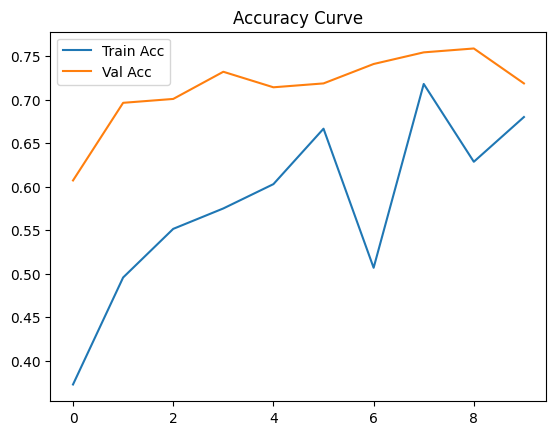

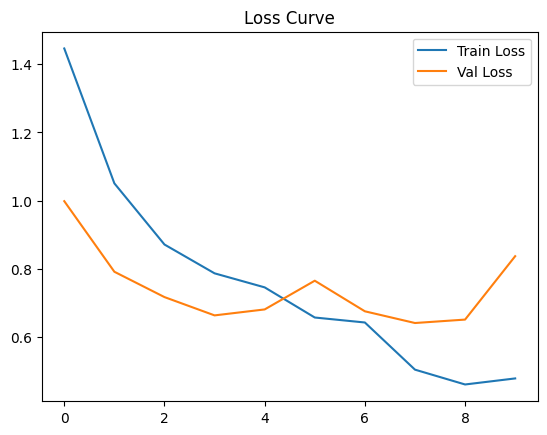

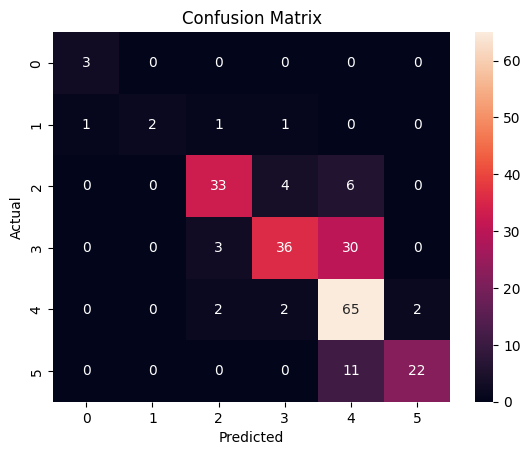

🔵 Running t-SNE...


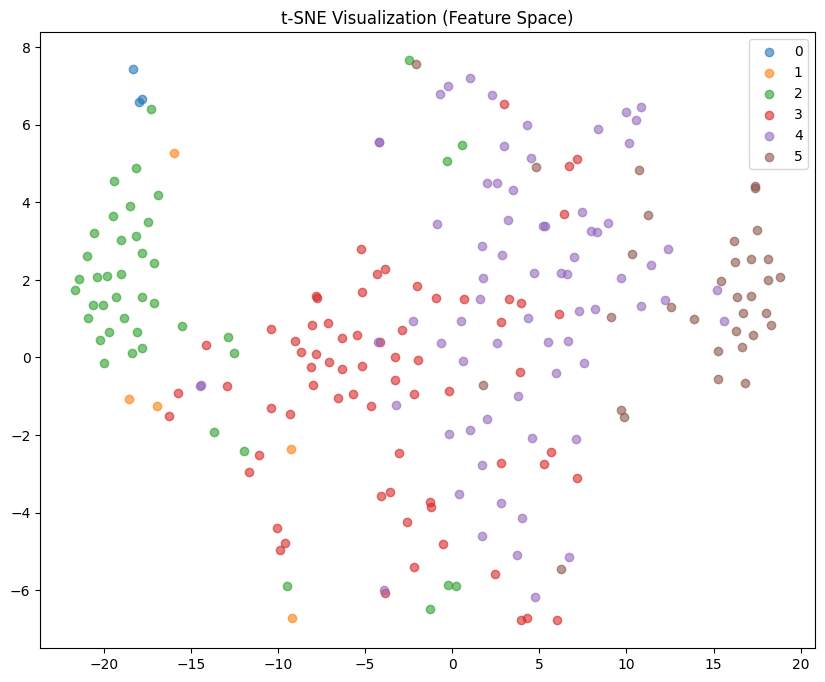

In [4]:
# ======================================================
# 🔹 IMPORTS
# ======================================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import copy
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torchvision.models import convnext_tiny
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE

# ======================================================
# 🔹 DEVICE
# ======================================================
device = "cuda" if torch.cuda.is_available() else "cpu"

# ======================================================
# 🔹 TRANSFORMS
# ======================================================
byol_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4,0.4,0.4,0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ======================================================
# 🔹 BACKBONE
# ======================================================
class Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        model = convnext_tiny(pretrained=True)
        self.features = model.features
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x, 1)  # [B,768]

# ======================================================
# 🔹 BYOL
# ======================================================
class MLP(nn.Module):
    def __init__(self, dim=768):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, dim)
        )

    def forward(self, x):
        return self.net(x)

class BYOL(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = Backbone()
        self.projector = MLP()
        self.predictor = MLP()

    def forward(self, x):
        f = self.backbone(x)
        z = self.projector(f)
        p = self.predictor(z)
        return p

def byol_loss(p, z):
    z = z.detach()
    p = nn.functional.normalize(p, dim=-1)
    z = nn.functional.normalize(z, dim=-1)
    return 2 - 2 * (p * z).sum(dim=-1).mean()

# ======================================================
# 🔹 BYOL PRETRAINING
# ======================================================
student = BYOL().to(device)
teacher = copy.deepcopy(student).to(device)

for p in teacher.parameters():
    p.requires_grad = False

optimizer = optim.Adam(student.parameters(), lr=1e-4)

dataset = datasets.ImageFolder("/content/drive/MyDrive/ResearchData/April26/6Classes", transform=byol_transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

momentum = 0.996

print("🔵 Starting BYOL pretraining...")
for epoch in range(5):
    for images, _ in loader:
        images = images.to(device)

        x1 = images
        x2 = images.flip(-1)

        p1 = student(x1)
        with torch.no_grad():
            z2 = teacher(x2)

        loss = byol_loss(p1, z2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # EMA update
        for ps, pt in zip(student.parameters(), teacher.parameters()):
            pt.data = momentum * pt.data + (1 - momentum) * ps.data

    print(f"BYOL Epoch {epoch+1} Loss: {loss.item():.4f}")

# ======================================================
# 🔹 SUPERVISED DATA
# ======================================================
full_dataset = datasets.ImageFolder("/content/drive/MyDrive/ResearchData/April26/6Classes", transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

# ======================================================
# 🔹 CLASSIFIER
# ======================================================
class Classifier(nn.Module):
    def __init__(self, backbone, num_classes):
        super().__init__()
        self.backbone = backbone
        self.fc = nn.Linear(768, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        return self.fc(x)

model = Classifier(student.backbone, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=3e-5)

# ======================================================
# 🔹 MIXUP
# ======================================================
def mixup_data(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0)).to(x.device)

    mixed_x = lam*x + (1-lam)*x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_loss(criterion, pred, y_a, y_b, lam):
    return lam*criterion(pred,y_a)+(1-lam)*criterion(pred,y_b)

# ======================================================
# 🔹 EVALUATION
# ======================================================
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    total_loss = 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()

            _, pred = torch.max(out, 1)
            correct += (pred == y).sum().item()
            total += y.size(0)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return total_loss/len(loader), correct/total, all_labels, all_preds

# ======================================================
# 🔹 TRAINING LOOP
# ======================================================
train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 10

print("🟢 Supervised training...")
for epoch in range(epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        x, y_a, y_b, lam = mixup_data(x, y)

        out = model(x)
        loss = mixup_loss(criterion, out, y_a, y_b, lam)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, pred = torch.max(out, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

# ======================================================
# 🔹 LEARNING CURVES
# ======================================================
plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

# ======================================================
# 🔹 CONFUSION MATRIX
# ======================================================
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ======================================================
# 🔹 t-SNE
# ======================================================
print("🔵 Running t-SNE...")

features = []
labels_list = []

model.eval()

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        feat = model.backbone(x)
        features.append(feat.cpu().numpy())
        labels_list.append(y.numpy())

features = np.concatenate(features, axis=0)
labels_list = np.concatenate(labels_list, axis=0)

# Speed optimization
if len(features) > 1500:
    idx = np.random.choice(len(features), 1500, replace=False)
    features = features[idx]
    labels_list = labels_list[idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(features)

plt.figure(figsize=(10,8))

for i in range(len(class_names)):
    idx = labels_list == i
    plt.scatter(tsne_result[idx,0], tsne_result[idx,1],
                label=class_names[i], alpha=0.6)

plt.legend()
plt.title("t-SNE Visualization (Feature Space)")
plt.show()